# Tomato Disease Detection - Full Training Pipeline

**DLT Mini Project** - Deep Learning Techniques

This notebook runs the **complete end-to-end pipeline** in Google Colab:
1. Downloads the PlantVillage tomato dataset from Kaggle
2. Preprocesses data with augmentation
3. Trains a MobileNetV2-based CNN (Transfer Learning)
4. Evaluates with Accuracy, Precision, Recall, F1, Confusion Matrix
5. Saves and downloads `tomato_model.h5`

**Runtime**: Set to **GPU** via `Runtime -> Change runtime type -> T4 GPU`

---
## 1. Install Dependencies and Check GPU

In [1]:
!pip install -q kagglehub scikit-learn matplotlib pillow

import tensorflow as tf
import numpy as np
import os, sys, json, zipfile, shutil
from pathlib import Path

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Enable memory growth for GPU
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. Download and Prepare the Dataset

Uses **kagglehub** to download the PlantVillage dataset.
Then extracts only the 10 Tomato disease classes.

In [2]:
import kagglehub

DATASET_DIR = Path("PlantVillage")

# The 10 tomato class folder names (as they appear in the dataset)
TOMATO_CLASSES = [
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato_healthy",
]

def is_image(p):
    return Path(p).suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}

def dataset_ready():
    if not DATASET_DIR.is_dir():
        return False
    dirs = [d for d in DATASET_DIR.iterdir() if d.is_dir()]
    imgs = sum(1 for d in dirs for f in d.iterdir() if is_image(str(f)))
    return len(dirs) >= 8 and imgs > 500


if dataset_ready():
    print(f"Dataset already exists at {DATASET_DIR}")
else:
    print("Downloading PlantVillage dataset from Kaggle...")
    path = kagglehub.dataset_download("arjuntejaswi/plant-village")
    print(f"Downloaded to: {path}")

    # Copy only tomato folders into PlantVillage/
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    src_root = Path(path)

    # Walk the downloaded directory to find tomato class folders
    found = 0
    for root, dirs, _ in os.walk(src_root):
        for d in dirs:
            if d in TOMATO_CLASSES or any(d.startswith(tc.split('_')[0]) and 'Tomato' in d for tc in TOMATO_CLASSES):
                # Check if this is actually a tomato class
                if d in TOMATO_CLASSES:
                    src = Path(root) / d
                    dest = DATASET_DIR / d
                    if dest.exists():
                        shutil.rmtree(dest)
                    shutil.copytree(src, dest)
                    n = sum(1 for f in dest.iterdir() if is_image(str(f)))
                    print(f"  Copied {d}: {n} images")
                    found += 1

    if found < 10:
        # Fallback: grab anything with 'Tomato' in the name
        print(f"  Found {found} exact matches. Trying loose 'Tomato' scan...")
        for root, dirs, _ in os.walk(src_root):
            for d in dirs:
                if 'Tomato' in d and d not in TOMATO_CLASSES:
                    src = Path(root) / d
                    dest = DATASET_DIR / d
                    if not dest.exists():
                        shutil.copytree(src, dest)
                        n = sum(1 for f in dest.iterdir() if is_image(str(f)))
                        print(f"  Copied {d}: {n} images")
                        found += 1

    print(f"\nOrganised {found} tomato class folders.")

# Remove non-tomato folders if any snuck in
if DATASET_DIR.is_dir():
    for d in DATASET_DIR.iterdir():
        if d.is_dir() and not d.name.startswith('Tomato'):
            shutil.rmtree(d)
            print(f"  Removed non-tomato folder: {d.name}")

# Print summary
if DATASET_DIR.is_dir():
    class_dirs = sorted([d for d in DATASET_DIR.iterdir() if d.is_dir()])
    total = 0
    print(f"\nDataset Summary ({len(class_dirs)} classes):")
    print("-" * 55)
    for cd in class_dirs:
        n = sum(1 for f in cd.iterdir() if is_image(str(f)))
        total += n
        print(f"  {cd.name:<50s} {n:>5}")
    print("-" * 55)
    print(f"  {'TOTAL':<50s} {total:>5}")

Using Colab cache for faster access to the 'plant-village' dataset.
Downloaded to: /kaggle/input/plant-village
  Copied Tomato_Leaf_Mold: 952 images
  Copied Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
  Copied Tomato_Bacterial_spot: 2127 images
  Copied Tomato_Septoria_leaf_spot: 1771 images
  Copied Tomato_healthy: 1591 images
  Copied Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
  Copied Tomato_Early_blight: 1000 images
  Copied Tomato__Target_Spot: 1404 images
  Copied Tomato_Late_blight: 1909 images
  Copied Tomato__Tomato_mosaic_virus: 373 images

Organised 10 tomato class folders.

Dataset Summary (10 classes):
-------------------------------------------------------
  Tomato_Bacterial_spot                               2127
  Tomato_Early_blight                                 1000
  Tomato_Late_blight                                  1909
  Tomato_Leaf_Mold                                     952
  Tomato_Septoria_leaf_spot                           1771
  To

---
## 3. Build the CNN Model (MobileNetV2 Transfer Learning)

In [3]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

IMG_SIZE    = 224
NUM_CLASSES = 10

# These must match the sorted folder names in PlantVillage/
CLASS_NAMES = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
print(f"Class names ({len(CLASS_NAMES)}): {CLASS_NAMES}")
assert len(CLASS_NAMES) == NUM_CLASSES, f"Expected {NUM_CLASSES} classes, found {len(CLASS_NAMES)}"


def build_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE, freeze_base=True):
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet",
    )
    base.trainable = not freeze_base

    model = models.Sequential([
        layers.InputLayer(input_shape=(img_size, img_size, 3)),
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def unfreeze_and_finetune(model, n_unfreeze=30, lr=1e-5):
    base = model.layers[1]
    base.trainable = True
    for layer in base.layers[:-n_unfreeze]:
        layer.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_model()
model.summary()

Class names (10): ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,226 (10.01 MB)

 Trainable params: 364,682 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

---
## 4. Prepare Data Generators (with Augmentation)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32
VAL_SPLIT  = 0.2
SEED       = 42

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
    validation_split=VAL_SPLIT,
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VAL_SPLIT,
)

common = dict(
    directory=str(DATASET_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    seed=SEED,
)

train_gen = train_datagen.flow_from_directory(**common, subset="training", shuffle=True)
val_gen   = val_datagen.flow_from_directory(**common, subset="validation", shuffle=False)

idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
print(f"\nClasses: {idx_to_class}")
print(f"Train: {train_gen.samples}  |  Val: {val_gen.samples}")

Found 12813 images belonging to 10 classes.
Found 3198 images belonging to 10 classes.

Classes: {0: 'Tomato_Bacterial_spot', 1: 'Tomato_Early_blight', 2: 'Tomato_Late_blight', 3: 'Tomato_Leaf_Mold', 4: 'Tomato_Septoria_leaf_spot', 5: 'Tomato_Spider_mites_Two_spotted_spider_mite', 6: 'Tomato__Target_Spot', 7: 'Tomato__Tomato_YellowLeaf__Curl_Virus', 8: 'Tomato__Tomato_mosaic_virus', 9: 'Tomato_healthy'}
Train: 12813  |  Val: 3198


---
## 5. Train - Phase 1: Feature Extraction (Frozen Backbone)

In [5]:
EPOCHS_P1 = 10

callbacks_p1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    ),
]

print("=" * 60)
print("  PHASE 1 - Feature Extraction")
print("=" * 60)

history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1,
    verbose=1,
)

  PHASE 1 - Feature Extraction
Epoch 1/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 241s 549ms/step - accuracy: 0.6470 - loss: 1.0639 - val_accuracy: 0.8124 - val_loss: 0.5522 - learning_rate: 0.0010
Epoch 2/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 189s 470ms/step - accuracy: 0.7656 - loss: 0.7027 - val_accuracy: 0.8540 - val_loss: 0.4470 - learning_rate: 0.0010
Epoch 3/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 190s 474ms/step - accuracy: 0.7940 - loss: 0.6184 - val_accuracy: 0.8574 - val_loss: 0.4182 - learning_rate: 0.0010
Epoch 4/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 191s 477ms/step - accuracy: 0.8100 - loss: 0.5586 - val_accuracy: 0.8609 - val_loss: 0.4074 - learning_rate: 0.0010
Epoch 5/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 193s 481ms/step - accuracy: 0.8246 - loss: 0.5261 - val_accuracy: 0.8884 - val_loss: 0.3692 - learning_rate: 0.0010
Epoch 6/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 192s 478ms/step - accuracy: 0.8338 - loss: 0.4991 - val_accuracy: 0.8821 - val_loss: 0.3558 - learning_rate: 0.0010
Epoch 7/10
401/401 ━━━━━━━━━━━━━━

---
## 6. Train - Phase 2: Fine-Tuning

In [7]:
EPOCHS_P2 = 5

# Fix: find MobileNetV2 base dynamically (isinstance, not index)
base = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base = layer
        break

base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "tomato_model.h5", monitor="val_accuracy", save_best_only=True, verbose=1
    ),
]

print("\n" + "=" * 60)
print("  PHASE 2 - Fine-Tuning (last 30 layers)")
print("=" * 60)

history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2,
    verbose=1,
)

# Merge histories
history = {}
for key in history_p1.history:
    history[key] = history_p1.history[key] + history_p2.history[key]

# Save class_indices.json
class_indices_inv = {str(v): k for k, v in train_gen.class_indices.items()}
with open("class_indices.json", "w") as f:
    json.dump(class_indices_inv, f, indent=2)
print("Saved class_indices.json")

# Final save
model.save("tomato_model.h5")
print("Model saved as tomato_model.h5")



  PHASE 2 - Fine-Tuning (last 30 layers)
Epoch 1/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.7706 - loss: 0.7177
Epoch 1: val_accuracy improved from None to 0.81770, saving model to tomato_model.h5



Epoch 1: finished saving model to tomato_model.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 228s 520ms/step - accuracy: 0.7864 - loss: 0.6635 - val_accuracy: 0.8177 - val_loss: 0.6194 - learning_rate: 1.0000e-05
Epoch 2/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8247 - loss: 0.5352
Epoch 2: val_accuracy improved from 0.81770 to 0.85241, saving model to tomato_model.h5



Epoch 2: finished saving model to tomato_model.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 192s 478ms/step - accuracy: 0.8246 - loss: 0.5361 - val_accuracy: 0.8524 - val_loss: 0.4874 - learning_rate: 1.0000e-05
Epoch 3/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.8419 - loss: 0.4791
Epoch 3: val_accuracy improved from 0.85241 to 0.87117, saving model to tomato_model.h5



Epoch 3: finished saving model to tomato_model.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 192s 480ms/step - accuracy: 0.8464 - loss: 0.4727 - val_accuracy: 0.8712 - val_loss: 0.4060 - learning_rate: 1.0000e-05
Epoch 4/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8510 - loss: 0.4353
Epoch 4: val_accuracy improved from 0.87117 to 0.88211, saving model to tomato_model.h5



Epoch 4: finished saving model to tomato_model.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 190s 473ms/step - accuracy: 0.8528 - loss: 0.4347 - val_accuracy: 0.8821 - val_loss: 0.3506 - learning_rate: 1.0000e-05
Epoch 5/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.8642 - loss: 0.4182
Epoch 5: val_accuracy improved from 0.88211 to 0.89337, saving model to tomato_model.h5



Epoch 5: finished saving model to tomato_model.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 199s 496ms/step - accuracy: 0.8680 - loss: 0.4134 - val_accuracy: 0.8934 - val_loss: 0.3116 - learning_rate: 1.0000e-05


Saved class_indices.json
Model saved as tomato_model.h5


---
## 7. Plot Training History (Accuracy and Loss)

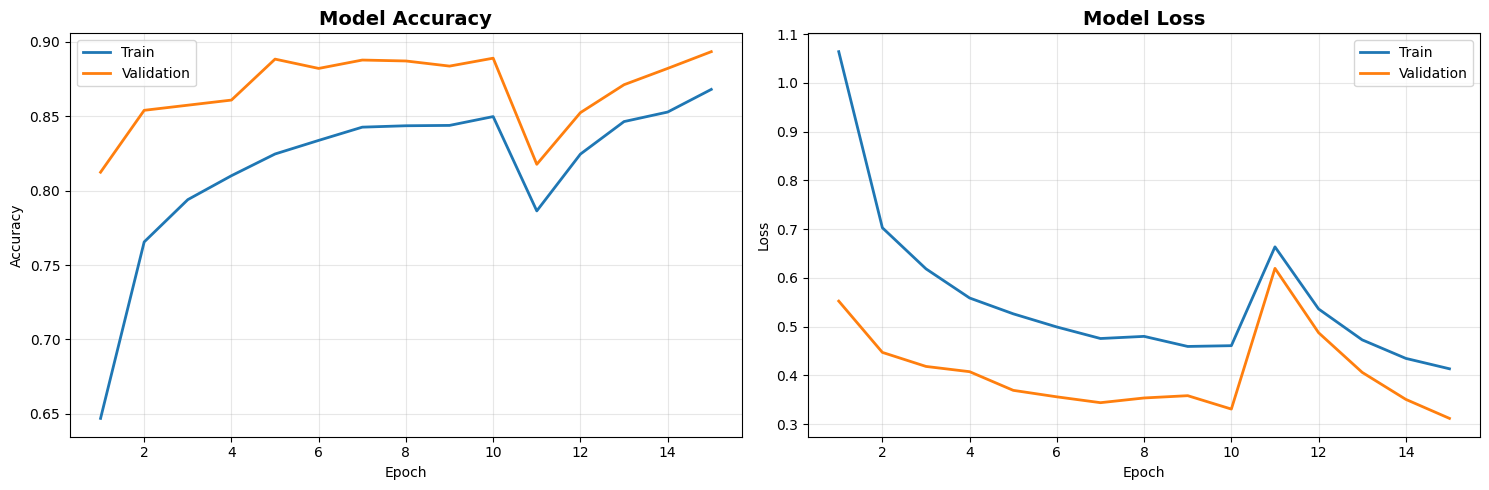

Saved training_history.png


In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["accuracy"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
ax1.plot(epochs_range, history["accuracy"], label="Train", linewidth=2)
ax1.plot(epochs_range, history["val_accuracy"], label="Validation", linewidth=2)
ax1.set_title("Model Accuracy", fontsize=14, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs_range, history["loss"], label="Train", linewidth=2)
ax2.plot(epochs_range, history["val_loss"], label="Validation", linewidth=2)
ax2.set_title("Model Loss", fontsize=14, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()
print("Saved training_history.png")

---
## 8. Evaluation - Confusion Matrix and Classification Report

In [9]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Predict on validation set
val_gen.reset()
y_pred_proba = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_gen.classes[:len(y_pred)]

class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

# Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec  = recall_score(y_true, y_pred, average="macro")
f1   = f1_score(y_true, y_pred, average="macro")

print("\n" + "=" * 60)
print("  EVALUATION METRICS")
print("=" * 60)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 60)

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\n" + report)

with open("classification_report.txt", "w") as f:
    f.write("Tomato Disease Detection - Classification Report\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Accuracy  : {acc:.4f}\n")
    f.write(f"Precision : {prec:.4f}\n")
    f.write(f"Recall    : {rec:.4f}\n")
    f.write(f"F1-Score  : {f1:.4f}\n\n")
    f.write(report)
print("Saved classification_report.txt")

100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step

  EVALUATION METRICS
  Accuracy  : 0.8934  (89.34%)
  Precision : 0.8808
  Recall    : 0.8735
  F1-Score  : 0.8670

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot     0.9224    0.9506    0.9363       425
                        Tomato_Early_blight     0.9293    0.4600    0.6154       200
                         Tomato_Late_blight     0.9441    0.8871    0.9147       381
                           Tomato_Leaf_Mold     0.8018    0.9368    0.8641       190
                  Tomato_Septoria_leaf_spot     0.8450    0.9237    0.8826       354
Tomato_Spider_mites_Two_spotted_spider_mite     0.9007    0.7851    0.8389       335
                        Tomato__Target_Spot     0.7248    0.8464    0.7809       280
      Tomato__Tomato_YellowLeaf__Curl_Virus     0.9860    0.9875    0.9867       641
                Tomato__Tomato_mosaic_virus     0.8571    0.9730    0.9114

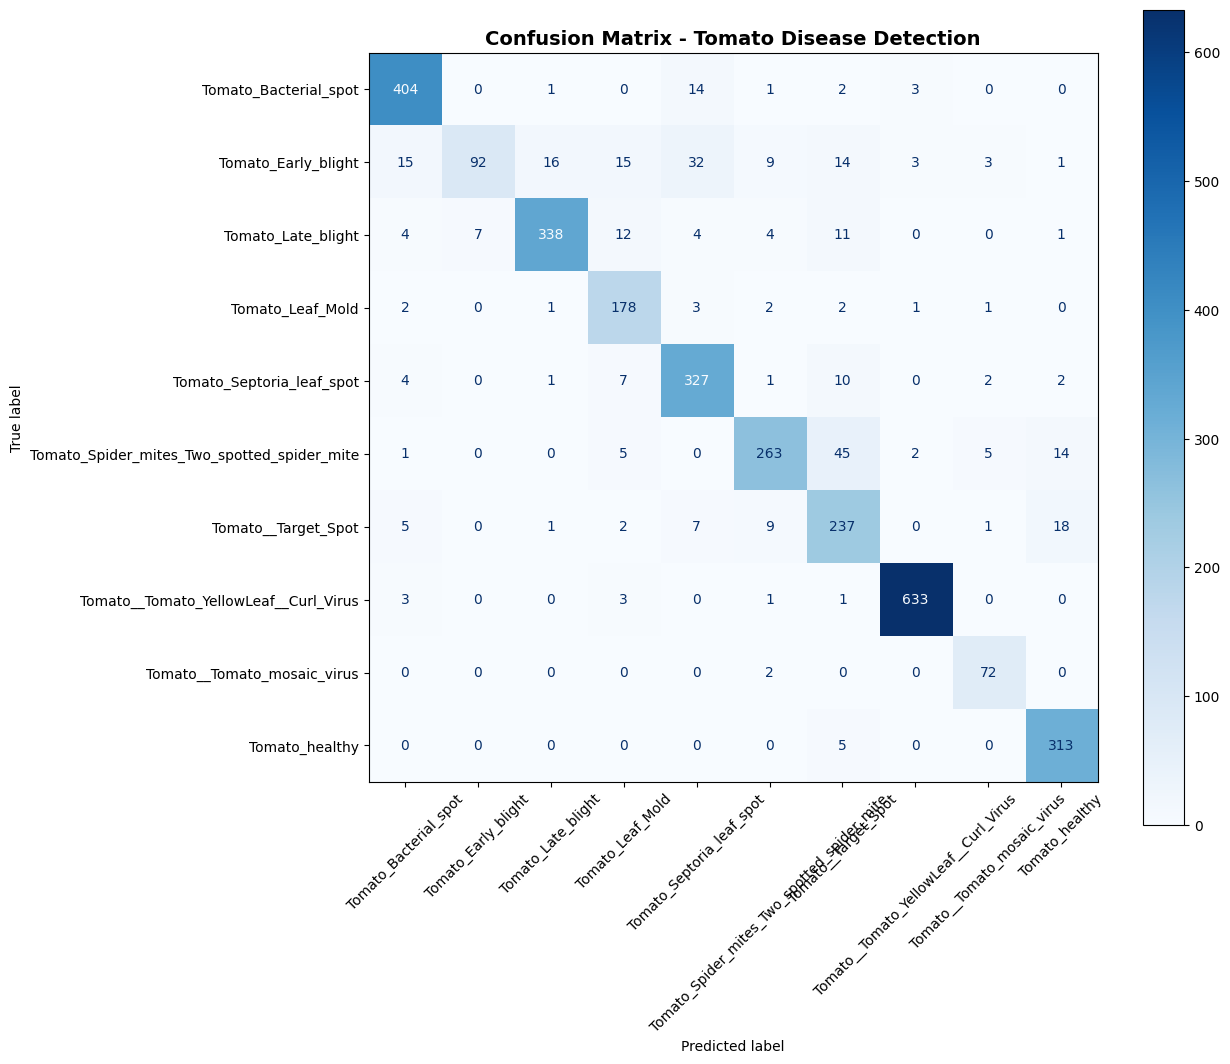

Saved confusion_matrix.png


In [10]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
ax.set_title("Confusion Matrix - Tomato Disease Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved confusion_matrix.png")

---
## 9. Download the Trained Model

Run the cell below to download `tomato_model.h5` to your local machine.

In [11]:
from google.colab import files

print("Downloading tomato_model.h5 ...")
files.download("tomato_model.h5")

print("Downloading class_indices.json ...")
files.download("class_indices.json")

print("Downloads triggered. Check your browser downloads.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered. Check your browser downloads.


---
## 10. (Optional) Download All Artifacts

In [12]:
# Download everything in one ZIP
from google.colab import files

artifacts = [
    "tomato_model.h5",
    "class_indices.json",
    "training_history.png",
    "confusion_matrix.png",
    "classification_report.txt",
]

out_zip = "tomato_disease_artifacts.zip"
with zipfile.ZipFile(out_zip, "w") as zf:
    for a in artifacts:
        if os.path.exists(a):
            zf.write(a)
            print(f"  Added {a}")

print(f"\nDownloading {out_zip} ...")
files.download(out_zip)

  Added tomato_model.h5
  Added class_indices.json
  Added training_history.png
  Added confusion_matrix.png
  Added classification_report.txt



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Done!

You now have:
- `tomato_model.h5` - trained model
- `class_indices.json` - class label mapping
- `training_history.png` - accuracy/loss curves
- `confusion_matrix.png` - confusion matrix
- `classification_report.txt` - precision, recall, F1

Copy `tomato_model.h5` and `class_indices.json` into the GitHub repo root and run `python main.py` to start the web app!